# HR Analytics Project
### Data Cleaning, Balancing & Visualization

This project focuses on analyzing HR data using data visualization techniques to understand employee attrition patterns.


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix


In [27]:
df = pd.read_csv("hr_data.csv")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [28]:
df.shape

(1470, 35)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [30]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


The dataset is clean and contains no missing values. Hence, no imputation is required.

## Target Variable Analysis: Attrition
Attrition indicates whether an employee has left the organization.


In [31]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

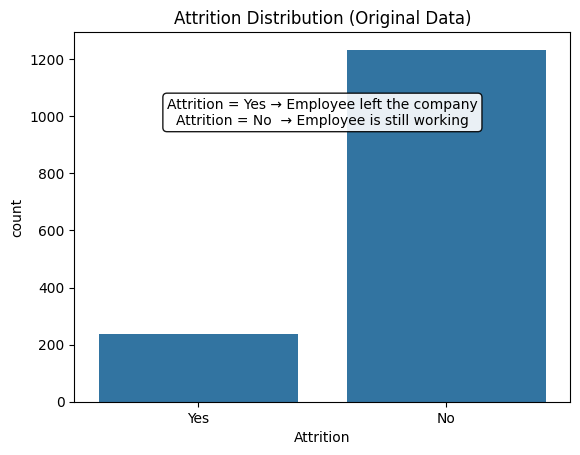

In [32]:
sns.countplot(x='Attrition', data=df)
plt.title("Attrition Distribution (Original Data)")
plt.text(
    0.5, 0.75,
    "Attrition = Yes → Employee left the company\n"
    "Attrition = No  → Employee is still working",
    transform=plt.gca().transAxes,
    ha='center',
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)
plt.show()

The dataset shows an imbalance between employees who left and those who stayed.

In [33]:
# DATA BALANCING
df_majority = df[df.Attrition == 'No']
df_minority = df[df.Attrition == 'Yes']

df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df_balanced = pd.concat([df_majority, df_minority_upsampled])

print("Balanced Attrition Count:")
print(df_balanced['Attrition'].value_counts())

Balanced Attrition Count:
Attrition
No     1233
Yes    1233
Name: count, dtype: int64


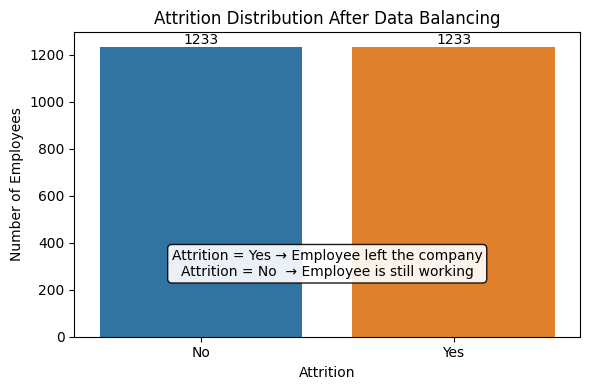

In [34]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df_balanced, palette=['#1f77b4', '#ff7f0e'])

plt.title("Attrition Distribution After Data Balancing")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

# Show values on bars
for p in plt.gca().patches:
    plt.gca().annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )
# 🔹 Explanation text inside graph
plt.text(
    0.5, 0.20,
    "Attrition = Yes → Employee left the company\n"
    "Attrition = No  → Employee is still working",
    transform=plt.gca().transAxes,
    ha='center',
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)
plt.tight_layout()
plt.show()

In [35]:
bins = [18, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65']

df_balanced['AgeGroup'] = pd.cut(df_balanced['Age'], bins=bins, labels=labels)


In [36]:
left_counts = (
    df_balanced[df_balanced['Attrition'] == 'Yes']['AgeGroup']
    .value_counts()
    .sort_index()
)

stay_counts = (
    df_balanced[df_balanced['Attrition'] == 'No']['AgeGroup']
    .value_counts()
    .sort_index()
)


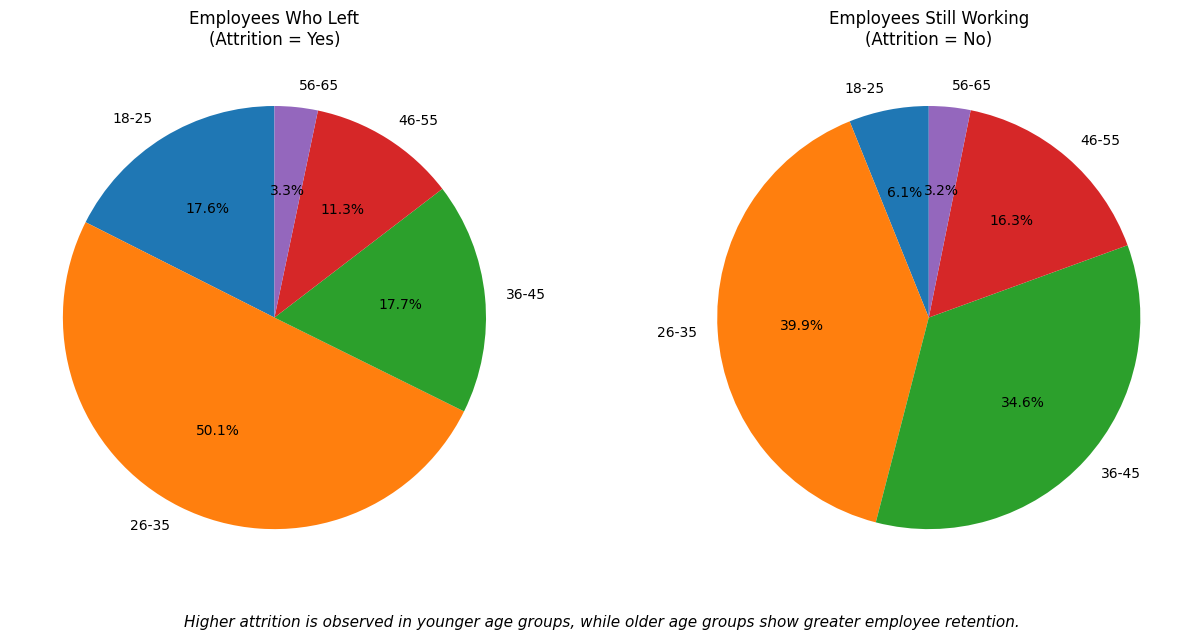

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13,6))

# Pie 1: Employees who LEFT
axes[0].pie(
    left_counts,
    labels=left_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title("Employees Who Left\n(Attrition = Yes)", fontsize=12)

# Pie 2: Employees who are STILL WORKING
axes[1].pie(
    stay_counts,
    labels=stay_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title("Employees Still Working\n(Attrition = No)", fontsize=12)

# 🔹 MAIN INSIGHT TEXT (CENTER / BOTTOM)
fig.text(
    0.5, -0.05,
    "Higher attrition is observed in younger age groups, while older age groups show greater employee retention.",
    ha='center',
    fontsize=11,
    style='italic'
)

plt.tight_layout()
plt.show()


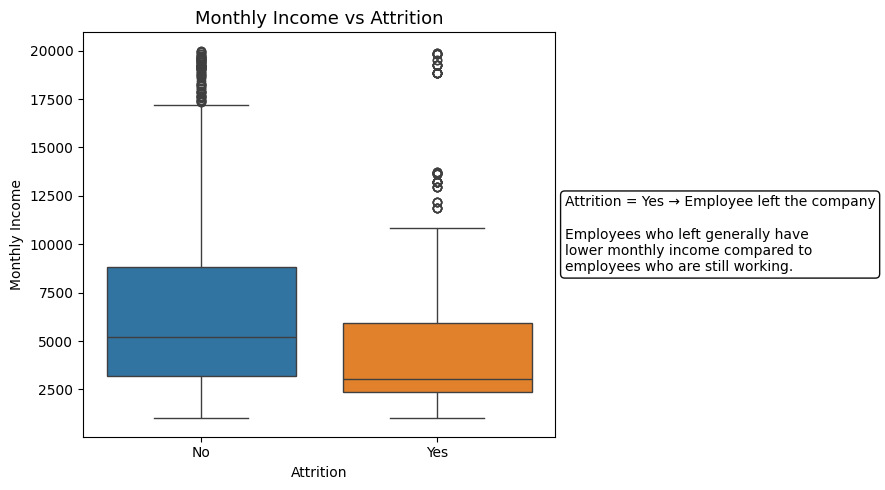

In [38]:
plt.figure(figsize=(9,5))  # thoda wide so text fit ho jaye

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df_balanced,
    palette=['#1f77b4', '#ff7f0e']
)

plt.title("Monthly Income vs Attrition", fontsize=13)
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

# 🔹 Meaning / Insight OUTSIDE graph (right side, very close)
plt.text(
    1.02, 0.5,
    "Attrition = Yes → Employee left the company\n\n"
    "Employees who left generally have\n"
    "lower monthly income compared to\n"
    "employees who are still working.",
    transform=plt.gca().transAxes,
    va='center',
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.95)
)

plt.tight_layout()
plt.show()


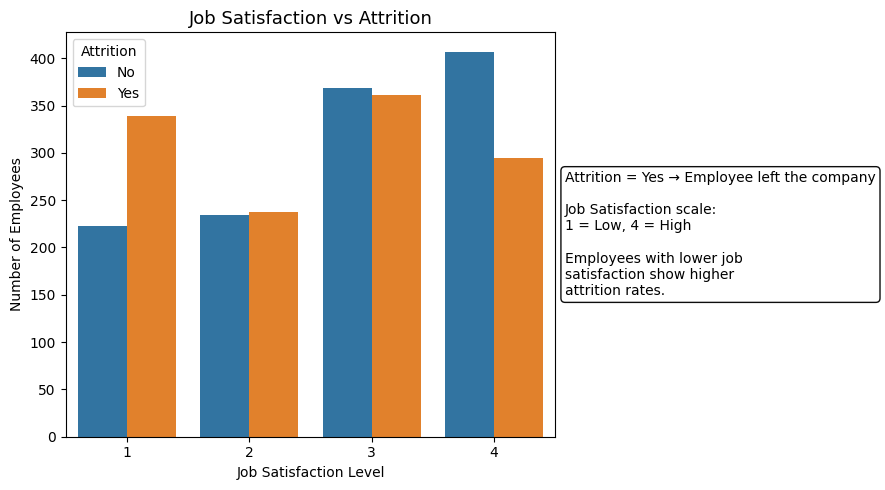

In [39]:
plt.figure(figsize=(9,5))

sns.countplot(
    x='JobSatisfaction',
    hue='Attrition',
    data=df_balanced,
    palette=['#1f77b4', '#ff7f0e']
)

plt.title("Job Satisfaction vs Attrition", fontsize=13)
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Number of Employees")

# 🔹 Meaning / Insight OUTSIDE graph (right side)
plt.text(
    1.02, 0.5,
    "Attrition = Yes → Employee left the company\n\n"
    "Job Satisfaction scale:\n"
    "1 = Low, 4 = High\n\n"
    "Employees with lower job\n"
    "satisfaction show higher\n"
    "attrition rates.",
    transform=plt.gca().transAxes,
    va='center',
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.95)
)

plt.tight_layout()
plt.show()


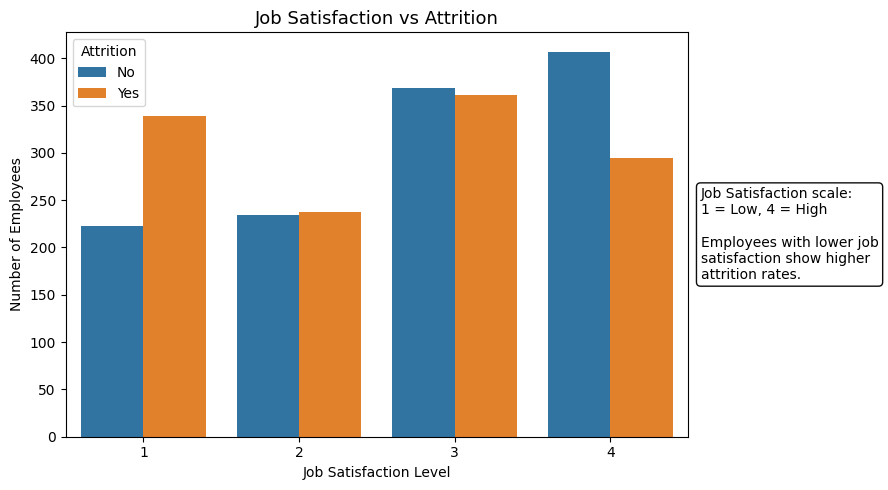

In [40]:
plt.figure(figsize=(9,5))

sns.countplot(
    x='JobSatisfaction',
    hue='Attrition',
    data=df_balanced,
    palette=['#1f77b4', '#ff7f0e']
)

plt.title("Job Satisfaction vs Attrition", fontsize=13)
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Number of Employees")

# 🔹 Meaning / Insight OUTSIDE graph (right side)
plt.text(
    1.02, 0.5,
    "Job Satisfaction scale:\n"
    "1 = Low, 4 = High\n\n"
    "Employees with lower job\n"
    "satisfaction show higher\n"
    "attrition rates.",
    transform=plt.gca().transAxes,
    va='center',
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.95)
)

plt.tight_layout()
plt.show()


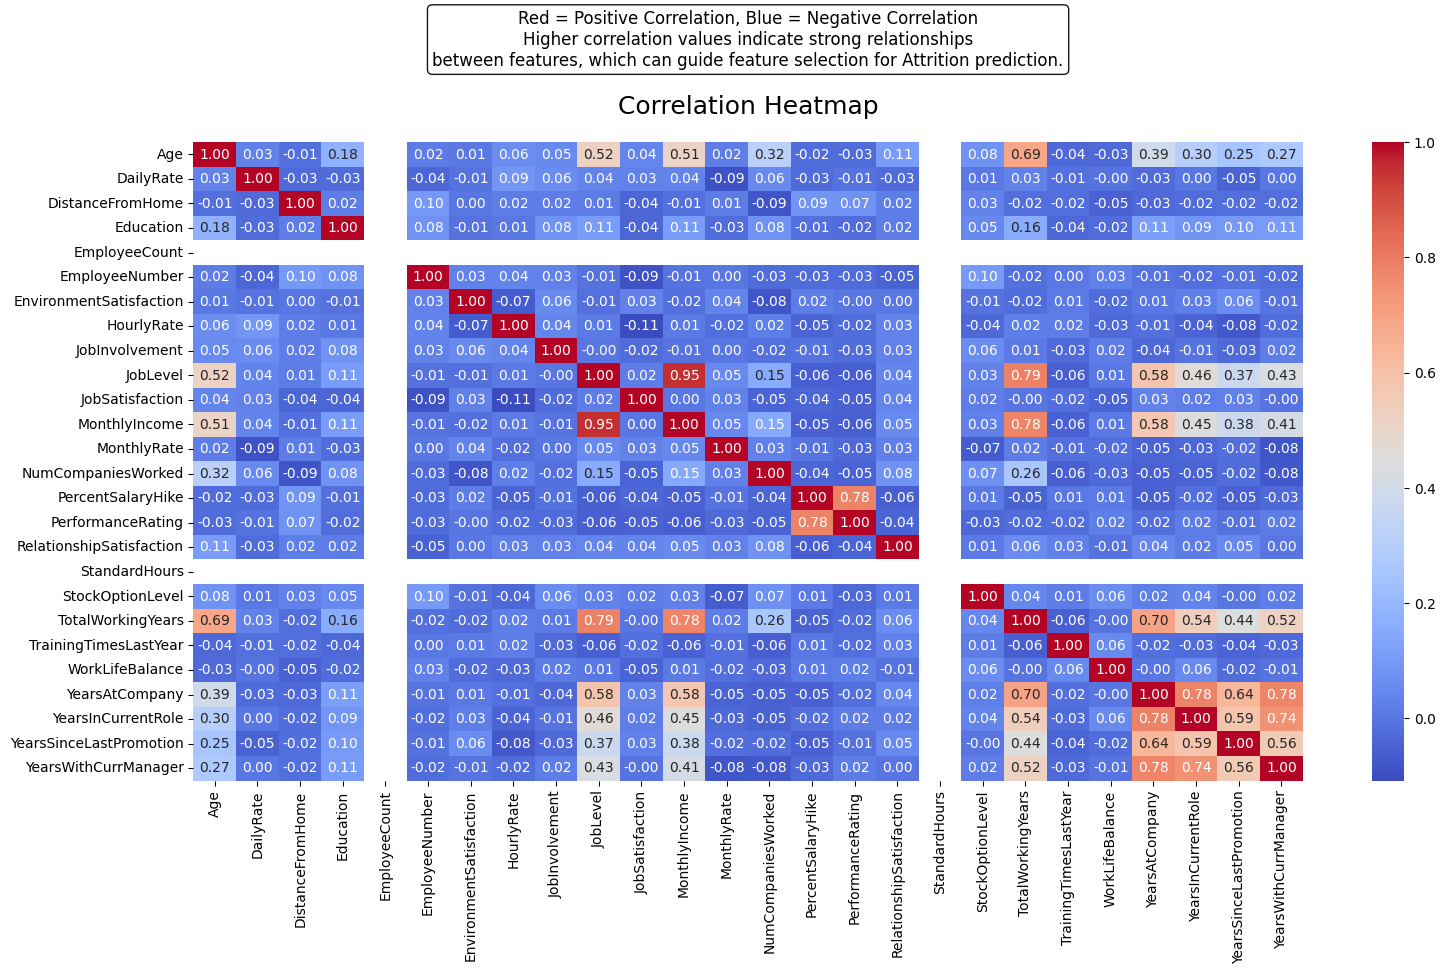

In [41]:
plt.figure(figsize=(16,10))  # Bigger heatmap

# 🔹 Plot heatmap
sns.heatmap(
    df_balanced.corr(numeric_only=True),
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    cbar=True
)

# 🔹 Title
plt.title("Correlation Heatmap", fontsize=18, pad=20)  # pad=space above

# 🔹 Explanation text ABOVE graph
plt.text(
    0.5, 1.12,  # x=0.5 center, y>1 means above plot
    "Red = Positive Correlation, Blue = Negative Correlation\n"
    "Higher correlation values indicate strong relationships\n"
    "between features, which can guide feature selection for Attrition prediction.",
    ha='center',
    fontsize=12,
    transform=plt.gca().transAxes,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9)
)

plt.tight_layout()
plt.show()


## Key Insights
- Younger employees show higher attrition rates.
- Employees with lower monthly income tend to leave more.
- Job satisfaction strongly affects employee retention.
- Certain departments experience higher employee turnover.
- Data visualization helps identify patterns before applying ML models.


## Conclusion
This HR Analytics project used data cleaning, balancing, and visualization techniques
to analyze employee attrition patterns. After preparing a balanced dataset, multiple
visualizations including age analysis, income distribution, job satisfaction trends,
and correlation heatmaps were used to extract meaningful insights.
These findings can help organizations make data-driven decisions to improve
employee retention and workforce planning.


Attrition 

Attrition = Yes → employee already company chhod chuka

Attrition = No → employee abhi company me hai

👉 Ye historical data hai (past information).

ML ka kaam :

Past employees ke data se pattern seekhna
aur current employees ke liye predict karna
ki wo future me company chhodenge ya nahi

Hum new attribute bana sakte hain, jaise:

Attrition_Predicted

Data Cleaning → DONE

EDA & Visualization → DONE

Data Balancing → DONE

Encoding → NEW

Train/Test Split → NEW

ML Model Training → NEW  ...Logistic Regression (BEST choice)

Evaluation (Accuracy + Confusion Matrix) → NEW

1️⃣ hr_data.csv

❌ Balanced nahi

❌ Use nahi ho raha training ke liye

2️⃣ df_balanced

✅ Balanced

✅ ML training isi pe hoti hai

👉 CSV sirf raw data ka storage hai.

CSV (original, imbalanced)
        ↓
Load into DataFrame (df)
        ↓
Balance in memory → df_balanced
        ↓
ML model train on df_balanced
        ↓
Prediction generated
        ↓
Save prediction to NEW CSV


In [42]:
y = df_balanced['Attrition'].map({'No': 0, 'Yes': 1})

X = df_balanced.drop([
    'Attrition',
    'EmployeeNumber',
    'EmployeeCount',
    'StandardHours'
], axis=1)

X = pd.get_dummies(X, drop_first=True)

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [44]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
#ml model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [45]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7267206477732794
Confusion Matrix:
 [[169  79]
 [ 56 190]]


In [46]:
df_balanced['Attrition_Predicted'] = model.predict(X)

df_balanced['Attrition_Predicted'] = df_balanced['Attrition_Predicted'].map({
    0: 'No',
    1: 'Yes'
})
#Add Prediction Column (IN MEMORY) "df_balanced" 

In [47]:
# df_balanced.to_csv("hr_attrition_predictions.csv", index=False)

print("Predicted data saved to hr_attrition_predictions.csv")

Predicted data saved to hr_attrition_predictions.csv


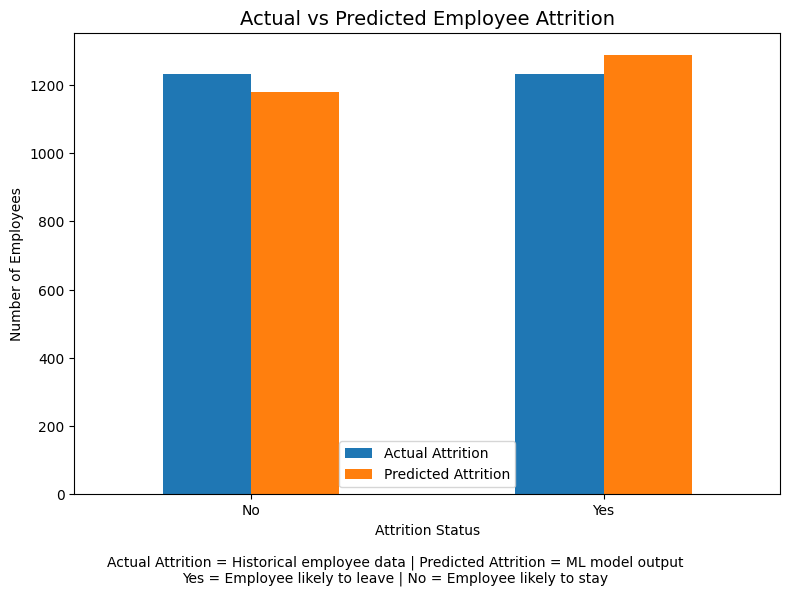

In [48]:
# Counts
actual_counts = df_balanced['Attrition'].value_counts()
pred_counts = df_balanced['Attrition_Predicted'].value_counts()

comparison_df = pd.DataFrame({
    'Actual Attrition': actual_counts,
    'Predicted Attrition': pred_counts
})

# Create figure
fig, ax = plt.subplots(figsize=(8,6))

# Plot bar chart
comparison_df.plot(kind='bar', ax=ax)

ax.set_title("Actual vs Predicted Employee Attrition", fontsize=14)
ax.set_xlabel("Attrition Status")
ax.set_ylabel("Number of Employees")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend()

# 🔹 Text BELOW graph (same figure, no box)
fig.text(
    0.5, 0.02,
    "Actual Attrition = Historical employee data | "
    "Predicted Attrition = ML model output\n"
    "Yes = Employee likely to leave | "
    "No = Employee likely to stay",
    ha='center',
    fontsize=10
)

# Adjust layout so text fits nicely
plt.tight_layout(rect=[0, 0.07, 1, 1])

plt.show()


## Machine Learning Results
The comparison between actual and predicted attrition shows that the model is able to
identify employees who are likely to leave or stay. The similarity between the bars
indicates that the Logistic Regression model has learned meaningful patterns from
the HR data.


In [50]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[169  79]
 [ 56 190]]


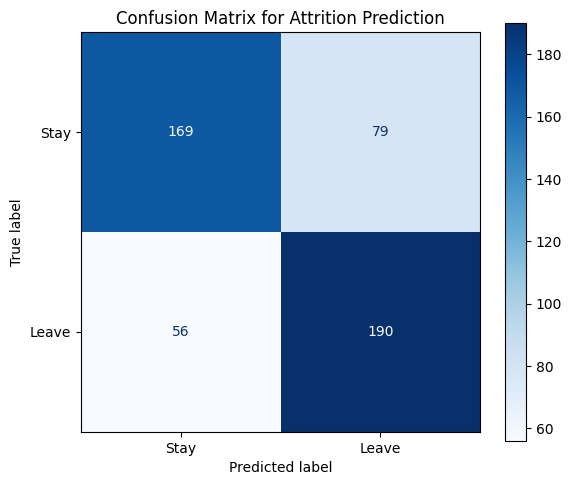

In [51]:
fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Stay', 'Leave']
).plot(ax=ax, cmap='Blues', values_format='d')

ax.set_title("Confusion Matrix for Attrition Prediction")
plt.tight_layout()
plt.show()

## Conclusion
This project analyzed HR data to understand employee attrition using data cleaning,
balancing, and visualization techniques. Exploratory analysis helped identify key
factors such as age, income, and job satisfaction that influence attrition.
A Logistic Regression model was trained on balanced data to predict future employee
attrition. The comparison of actual and predicted results along with the confusion
matrix demonstrates the effectiveness of the machine learning approach.
This project highlights how data visualization and machine learning together can
support data-driven HR decision-making.


CSV / Notebook
      ↓
JSON (Horizontal format)
      ↓
MongoDB (store)
      ↓
Express + Node (API)
      ↓
React (Dashboard UI)


In [52]:
# Select important columns for dashboard
dashboard_df = df_balanced[[
    'Age',
    'Department',
    'JobSatisfaction',
    'MonthlyIncome',
    'Attrition',
    'Attrition_Predicted'
]]

# Convert to JSON (horizontal)
dashboard_df.to_json(
    "hr_dashboard_data.json",
    orient="records",
    indent=4
)

print("JSON file created: hr_dashboard_data.json")

JSON file created: hr_dashboard_data.json
